In [1]:
# ============================================================
# PROJECT 16 — FINANCIAL CUSTOMER DATA QUALITY
# STEP 1 — LOAD DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Download Bank Marketing dataset
# ------------------------------------------------------------

url = (
    "https://archive.ics.uci.edu/"
    "ml/machine-learning-databases/00222/"
    "bank.zip"
)

print("=" * 70)
print("PROJECT 16 — FINANCIAL CUSTOMER DATA QUALITY")
print("=" * 70)

print("\nDownloading dataset...")

import requests
import zipfile
import io

response = requests.get(
    url,
    timeout=120
)

response.raise_for_status()

print(
    f"Downloaded: "
    f"{len(response.content) / (1024**2):.2f} MB"
)

# ------------------------------------------------------------
# Extract ZIP in memory
# ------------------------------------------------------------

with zipfile.ZipFile(
    io.BytesIO(response.content)
) as z:

    print("\nFiles inside ZIP:")
    print(z.namelist())

    # Read bank-full.csv
    with z.open(
        "bank-full.csv"
    ) as file:

        df = pd.read_csv(
            file,
            sep=";"
        )

# ------------------------------------------------------------
# Basic dataset information
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(
    f"\nShape: {df.shape}"
)

print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)

print(
    "\nData types:"
)

print(
    df.dtypes
)

print(
    "\nFirst 5 rows:"
)

display(
    df.head()
)

PROJECT 16 — FINANCIAL CUSTOMER DATA QUALITY

Downloaded: 0.55 MB

Files inside ZIP:
['bank-full.csv', 'bank-names.txt', 'bank.csv']

DATASET INFORMATION

Shape: (45211, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
# ============================================================
# STEP 2 — DATA QUALITY PROFILING
# ============================================================

# ------------------------------------------------------------
# 1. Basic dimensions
# ------------------------------------------------------------

rows = len(df)
columns = len(df.columns)

print("=" * 70)
print("DATA QUALITY PROFILING")
print("=" * 70)

print(
    f"\nRows    : {rows:,}"
)

print(
    f"Columns : {columns}"
)

# ------------------------------------------------------------
# 2. Missing values
# ------------------------------------------------------------

missing = (
    df.isnull()
    .sum()
)

missing_percentage = (
    missing / rows * 100
)

missing_report = pd.DataFrame({
    "Column": missing.index,
    "Missing": missing.values,
    "Missing_Percentage":
        missing_percentage.values
})

missing_report = (
    missing_report
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

print("\nMissing Value Report:")
display(
    missing_report
)

# ------------------------------------------------------------
# 3. Duplicate records
# ------------------------------------------------------------

duplicate_count = (
    df.duplicated().sum()
)

duplicate_percentage = (
    duplicate_count
    / rows
    * 100
)

print(
    "\nDuplicate Records:"
)

print(
    f"Count      : {duplicate_count:,}"
)

print(
    f"Percentage : "
    f"{duplicate_percentage:.4f}%"
)

# ------------------------------------------------------------
# 4. Unique values
# ------------------------------------------------------------

unique_report = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [
        df[col].nunique(
            dropna=False
        )
        for col in df.columns
    ]
})

unique_report[
    "Uniqueness_Percentage"
] = (
    unique_report[
        "Unique_Values"
    ]
    / rows
    * 100
)

print(
    "\nUnique Value Report:"
)

display(
    unique_report
)

# ------------------------------------------------------------
# 5. Summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA QUALITY SUMMARY")
print("=" * 70)

print(
    f"Total rows           : {rows:,}"
)

print(
    f"Total columns        : {columns}"
)

print(
    f"Total missing values : "
    f"{missing.sum():,}"
)

print(
    f"Duplicate rows       : "
    f"{duplicate_count:,}"
)

DATA QUALITY PROFILING

Rows    : 45,211
Columns : 17

Missing Value Report:


,Column,Missing,Missing_Percentage
0,age,0,0.0
1,job,0,0.0
2,marital,0,0.0
3,education,0,0.0
4,default,0,0.0
5,balance,0,0.0
6,housing,0,0.0
7,loan,0,0.0
8,contact,0,0.0
9,day,0,0.0



Duplicate Records:
Count      : 0
Percentage : 0.0000%

Unique Value Report:


,Column,Unique_Values,Uniqueness_Percentage
0,age,77,0.170313
1,job,12,0.026542
2,marital,3,0.006636
3,education,4,0.008847
4,default,2,0.004424
5,balance,7168,15.854549
6,housing,2,0.004424
7,loan,2,0.004424
8,contact,3,0.006636
9,day,31,0.068567



DATA QUALITY SUMMARY
Total rows           : 45,211
Total columns        : 17
Total missing values : 0
Duplicate rows       : 0


In [3]:
# ============================================================
# STEP 3 — DATA TYPE & VALIDITY AUDIT
# ============================================================

# ------------------------------------------------------------
# 1. Define expected business rules
# ------------------------------------------------------------

rules = {}

# Age should be positive and within realistic range
rules["age"] = (
    df["age"].between(
        18,
        100
    )
)

# Balance should not be negative
rules["balance"] = (
    df["balance"] >= 0
)

# Day should be between 1 and 31
rules["day"] = (
    df["day"].between(
        1,
        31
    )
)

# Duration should not be negative
rules["duration"] = (
    df["duration"] >= 0
)

# Campaign should not be negative
rules["campaign"] = (
    df["campaign"] >= 0
)

# Pdays = -1 means customer was not previously contacted
rules["pdays"] = (
    (df["pdays"] == -1)
    |
    (df["pdays"] >= 0)
)

# Previous contacts cannot be negative
rules["previous"] = (
    df["previous"] >= 0
)

# ------------------------------------------------------------
# 2. Create validity report
# ------------------------------------------------------------

validity_rows = []

for column, condition in rules.items():

    invalid_count = (
        (~condition).sum()
    )

    valid_count = (
        condition.sum()
    )

    validity_rate = (
        valid_count
        / len(df)
        * 100
    )

    validity_rows.append({
        "Column": column,
        "Valid_Rows": valid_count,
        "Invalid_Rows": invalid_count,
        "Validity_Rate": validity_rate
    })

validity_report = pd.DataFrame(
    validity_rows
)

# ------------------------------------------------------------
# 3. Display
# ------------------------------------------------------------

print("=" * 70)
print("VALIDITY AUDIT")
print("=" * 70)

display(
    validity_report
)

# ------------------------------------------------------------
# 4. Invalid records
# ------------------------------------------------------------

total_invalid = (
    validity_report[
        "Invalid_Rows"
    ].sum()
)

print(
    f"\nTotal invalid observations "
    f"across monitored fields: "
    f"{total_invalid:,}"
)

VALIDITY AUDIT


,Column,Valid_Rows,Invalid_Rows,Validity_Rate
0,age,45211,0,100.000000
1,balance,41445,3766,91.670169
2,day,45211,0,100.000000
3,duration,45211,0,100.000000
4,campaign,45211,0,100.000000
5,pdays,45211,0,100.000000
6,previous,45211,0,100.000000



Total invalid observations across monitored fields: 3,766


OUTLIER ANALYSIS


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outliers,Outlier_Percentage
6,previous,0.0,0.0,0.0,0.0,0.0,8257,18.263255
5,pdays,-1.0,-1.0,0.0,-1.0,-1.0,8257,18.263255
1,balance,72.0,1428.0,1356.0,-1962.0,3462.0,4729,10.459844
3,duration,103.0,319.0,216.0,-221.0,643.0,3235,7.155338
4,campaign,1.0,3.0,2.0,-2.0,6.0,3064,6.777112
0,age,33.0,48.0,15.0,10.5,70.5,487,1.077171
2,day,8.0,21.0,13.0,-11.5,40.5,0,0.000000


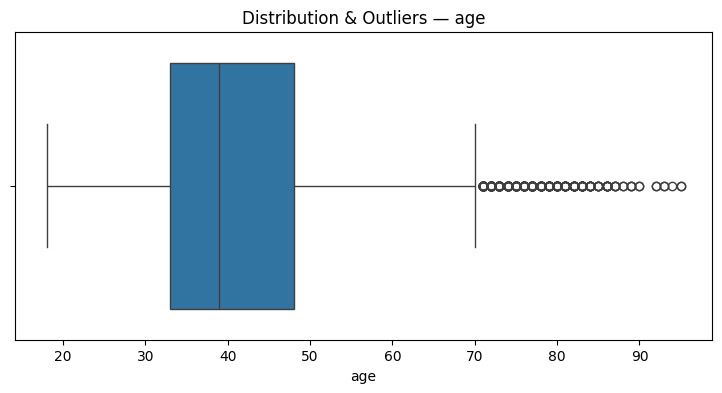

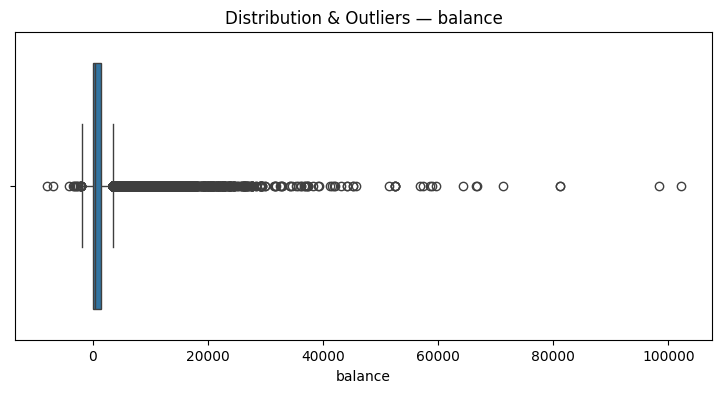

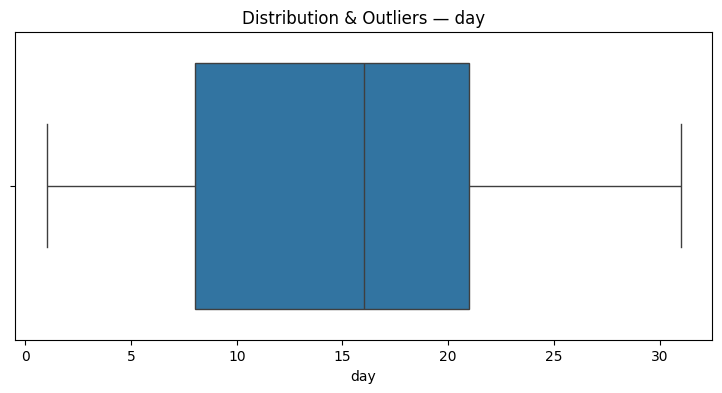

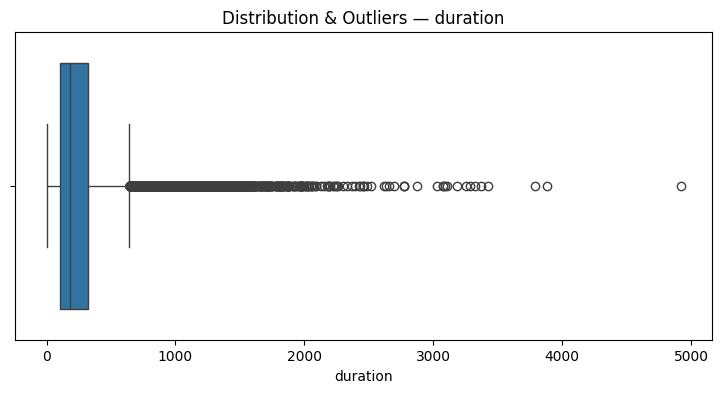

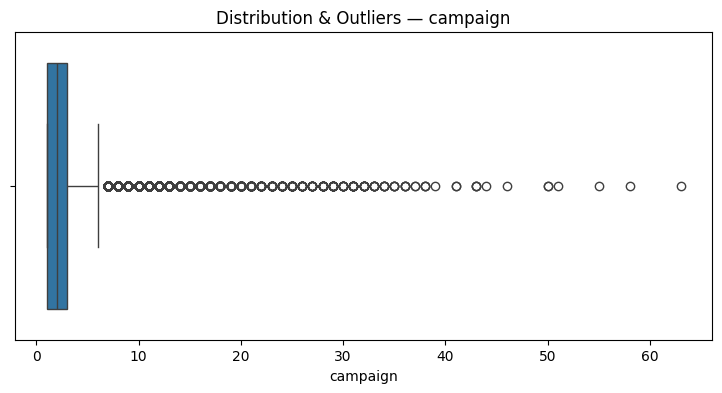

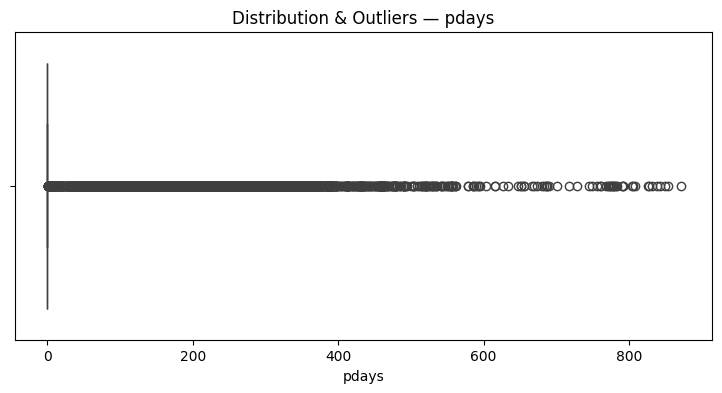

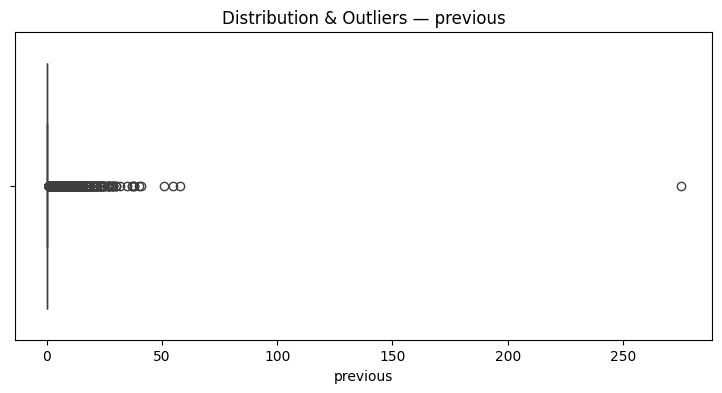

In [4]:
# ============================================================
# STEP 4 — OUTLIER DETECTION
# ============================================================

numeric_columns = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

outlier_results = []

for column in numeric_columns:

    Q1 = df[column].quantile(
        0.25
    )

    Q3 = df[column].quantile(
        0.75
    )

    IQR = Q3 - Q1

    lower_bound = (
        Q1 - 1.5 * IQR
    )

    upper_bound = (
        Q3 + 1.5 * IQR
    )

    outliers = (
        (df[column] < lower_bound)
        |
        (df[column] > upper_bound)
    )

    outlier_count = (
        outliers.sum()
    )

    outlier_percentage = (
        outlier_count
        / len(df)
        * 100
    )

    outlier_results.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outliers": outlier_count,
        "Outlier_Percentage":
            outlier_percentage
    })

outlier_report = pd.DataFrame(
    outlier_results
)

outlier_report = (
    outlier_report
    .sort_values(
        "Outlier_Percentage",
        ascending=False
    )
)

print("=" * 70)
print("OUTLIER ANALYSIS")
print("=" * 70)

display(
    outlier_report
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

for column in numeric_columns:

    plt.figure(
        figsize=(9, 4)
    )

    sns.boxplot(
        x=df[column]
    )

    plt.title(
        f"Distribution & Outliers — {column}"
    )

    plt.xlabel(column)

    plt.show()

In [5]:
# ============================================================
# STEP 5 — CATEGORICAL CONSISTENCY AUDIT
# ============================================================

categorical_columns = [
    column
    for column in df.columns
    if df[column].dtype == "object"
]

print("=" * 70)
print("CATEGORICAL CONSISTENCY AUDIT")
print("=" * 70)

category_summary = []

for column in categorical_columns:

    unique_count = (
        df[column]
        .nunique(
            dropna=False
        )
    )

    sample_values = (
        df[column]
        .value_counts(
            dropna=False
        )
        .head(10)
        .to_dict()
    )

    category_summary.append({
        "Column": column,
        "Unique_Values": unique_count,
        "Top_Values": sample_values
    })

category_report = pd.DataFrame(
    category_summary
)

display(
    category_report
)

# ------------------------------------------------------------
# Detailed categories
# ------------------------------------------------------------

for column in categorical_columns:

    print(
        f"\n{column}"
    )

    print(
        df[column]
        .value_counts(
            dropna=False
        )
    )

CATEGORICAL CONSISTENCY AUDIT


,Column,Unique_Values,Top_Values
0,job,12,"{'blue-collar': 9732, 'management': 9458, 'tec..."
1,marital,3,"{'married': 27214, 'single': 12790, 'divorced'..."
2,education,4,"{'secondary': 23202, 'tertiary': 13301, 'prima..."
3,default,2,"{'no': 44396, 'yes': 815}"
4,housing,2,"{'yes': 25130, 'no': 20081}"
5,loan,2,"{'no': 37967, 'yes': 7244}"
6,contact,3,"{'cellular': 29285, 'unknown': 13020, 'telepho..."
7,month,12,"{'may': 13766, 'jul': 6895, 'aug': 6247, 'jun'..."
8,poutcome,4,"{'unknown': 36959, 'failure': 4901, 'other': 1..."
9,y,2,"{'no': 39922, 'yes': 5289}"



job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default
default
no     44396
yes      815
Name: count, dtype: int64

housing
housing
yes    25130
no     20081
Name: count, dtype: int64

loan
loan
no     37967
yes     7244
Name: count, dtype: int64

contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count

In [6]:
# ============================================================
# STEP 6 — DATA QUALITY SCORE
# ============================================================

# ------------------------------------------------------------
# 1. Completeness
# ------------------------------------------------------------

completeness_score = (
    1
    -
    df.isnull()
    .sum()
    .sum()
    /
    (df.shape[0] * df.shape[1])
) * 100

# ------------------------------------------------------------
# 2. Uniqueness
# ------------------------------------------------------------

duplicate_rate = (
    df.duplicated().mean()
)

uniqueness_score = (
    1 - duplicate_rate
) * 100

# ------------------------------------------------------------
# 3. Validity
# ------------------------------------------------------------

validity_score = (
    validity_report[
        "Validity_Rate"
    ].mean()
)

# ------------------------------------------------------------
# 4. Outlier-adjusted score
# ------------------------------------------------------------

average_outlier_rate = (
    outlier_report[
        "Outlier_Percentage"
    ].mean()
)

anomaly_score = max(
    0,
    100 - average_outlier_rate
)

# ------------------------------------------------------------
# 5. Overall Data Quality Score
# ------------------------------------------------------------

overall_quality_score = (
    completeness_score * 0.30
    +
    uniqueness_score * 0.20
    +
    validity_score * 0.30
    +
    anomaly_score * 0.20
)

quality_score = pd.DataFrame({
    "Dimension": [
        "Completeness",
        "Uniqueness",
        "Validity",
        "Anomaly-Free Rate",
        "Overall Quality"
    ],
    "Score": [
        completeness_score,
        uniqueness_score,
        validity_score,
        anomaly_score,
        overall_quality_score
    ]
})

print("=" * 70)
print("DATA QUALITY SCORE")
print("=" * 70)

display(
    quality_score
)

print(
    f"\nOverall Data Quality Score: "
    f"{overall_quality_score:.2f}/100"
)

DATA QUALITY SCORE


,Dimension,Score
0,Completeness,100.000000
1,Uniqueness,100.000000
2,Validity,98.810024
3,Anomaly-Free Rate,91.143432
4,Overall Quality,97.871694



Overall Data Quality Score: 97.87/100


In [7]:
# ============================================================
# STEP 7 — MACHINE LEARNING ANOMALY DETECTION
# ============================================================

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Prepare numeric features
# ------------------------------------------------------------

X_anomaly = (
    df[numeric_columns]
    .copy()
)

# ------------------------------------------------------------
# 2. Handle missing values
# ------------------------------------------------------------

X_anomaly = (
    X_anomaly
    .fillna(
        X_anomaly.median()
    )
)

# ------------------------------------------------------------
# 3. Standardize
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_anomaly
)

# ------------------------------------------------------------
# 4. Isolation Forest
# ------------------------------------------------------------

isolation_model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

anomaly_prediction = (
    isolation_model
    .fit_predict(
        X_scaled
    )
)

anomaly_score_values = (
    isolation_model
    .decision_function(
        X_scaled
    )
)

# ------------------------------------------------------------
# 5. Create anomaly result
# ------------------------------------------------------------

anomaly_df = df.copy()

anomaly_df[
    "Anomaly_Label"
] = anomaly_prediction

anomaly_df[
    "Anomaly_Score"
] = anomaly_score_values

anomaly_df[
    "Anomaly_Status"
] = np.where(
    anomaly_prediction == -1,
    "Anomaly",
    "Normal"
)

# ------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------

anomaly_summary = (
    anomaly_df[
        "Anomaly_Status"
    ]
    .value_counts()
)

print("=" * 70)
print("MACHINE LEARNING ANOMALY DETECTION")
print("=" * 70)

print(
    "\nAnomaly distribution:"
)

display(
    anomaly_summary
)

print(
    "\nAnomaly percentage:"
)

display(
    (
        anomaly_summary
        / len(df)
        * 100
    ).round(4)
)

MACHINE LEARNING ANOMALY DETECTION

Anomaly distribution:


,count
Anomaly_Status,
Normal,44306
Anomaly,905



Anomaly percentage:


,count
Anomaly_Status,
Normal,97.9983
Anomaly,2.0017


In [8]:
# ============================================================
# STEP 8 — ANOMALY PROFILING
# ============================================================

normal_profile = (
    anomaly_df[
        anomaly_df[
            "Anomaly_Status"
        ] == "Normal"
    ][numeric_columns]
    .mean()
)

anomaly_profile = (
    anomaly_df[
        anomaly_df[
            "Anomaly_Status"
        ] == "Anomaly"
    ][numeric_columns]
    .mean()
)

profile_comparison = pd.DataFrame({
    "Feature": numeric_columns,
    "Normal_Mean": [
        normal_profile[col]
        for col in numeric_columns
    ],
    "Anomaly_Mean": [
        anomaly_profile[col]
        for col in numeric_columns
    ]
})

profile_comparison[
    "Difference"
] = (
    profile_comparison[
        "Anomaly_Mean"
    ]
    -
    profile_comparison[
        "Normal_Mean"
    ]
)

print("=" * 70)
print("ANOMALY PROFILE")
print("=" * 70)

display(
    profile_comparison
)

ANOMALY PROFILE


,Feature,Normal_Mean,Anomaly_Mean,Difference
0,age,40.852526,45.033149,4.180624
1,balance,1276.511849,5560.826519,4284.314670
2,day,15.808807,15.689503,-0.119304
3,duration,254.668149,429.264088,174.595940
4,campaign,2.699409,5.918232,3.218823
5,pdays,36.640906,214.333702,177.692795
6,previous,0.432808,7.802210,7.369402


In [9]:
# ============================================================
# STEP 9 — DATA QUALITY ISSUE REGISTER
# ============================================================

issues = []

# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

for _, row in missing_report.iterrows():

    if row["Missing"] > 0:

        issues.append({
            "Issue_Type": "Completeness",
            "Field": row["Column"],
            "Issue_Count": row["Missing"],
            "Issue_Rate":
                row["Missing_Percentage"],
            "Severity": (
                "High"
                if row["Missing_Percentage"] > 10
                else "Medium"
                if row["Missing_Percentage"] > 1
                else "Low"
            )
        })

# ------------------------------------------------------------
# Duplicate records
# ------------------------------------------------------------

if duplicate_count > 0:

    issues.append({
        "Issue_Type": "Uniqueness",
        "Field": "Entire Record",
        "Issue_Count": duplicate_count,
        "Issue_Rate":
            duplicate_percentage,
        "Severity": (
            "High"
            if duplicate_percentage > 5
            else "Medium"
        )
    })

# ------------------------------------------------------------
# Invalid records
# ------------------------------------------------------------

for _, row in validity_report.iterrows():

    if row["Invalid_Rows"] > 0:

        invalid_rate = (
            100 -
            row["Validity_Rate"]
        )

        issues.append({
            "Issue_Type": "Validity",
            "Field": row["Column"],
            "Issue_Count":
                row["Invalid_Rows"],
            "Issue_Rate":
                invalid_rate,
            "Severity": (
                "High"
                if invalid_rate > 5
                else "Medium"
                if invalid_rate > 1
                else "Low"
            )
        })

# ------------------------------------------------------------
# Statistical outliers
# ------------------------------------------------------------

for _, row in outlier_report.iterrows():

    if row["Outliers"] > 0:

        issues.append({
            "Issue_Type": "Statistical Outlier",
            "Field": row["Feature"],
            "Issue_Count":
                row["Outliers"],
            "Issue_Rate":
                row["Outlier_Percentage"],
            "Severity": (
                "High"
                if row["Outlier_Percentage"] > 10
                else "Medium"
                if row["Outlier_Percentage"] > 5
                else "Low"
            )
        })

issue_register = pd.DataFrame(
    issues
)

if len(issue_register) > 0:

    issue_register = (
        issue_register
        .sort_values(
            [
                "Severity",
                "Issue_Rate"
            ],
            ascending=[
                True,
                False
            ]
        )
    )

print("=" * 70)
print("DATA QUALITY ISSUE REGISTER")
print("=" * 70)

if len(issue_register) > 0:

    display(
        issue_register
    )

else:

    print(
        "No data quality issues detected "
        "under the defined rules."
    )

DATA QUALITY ISSUE REGISTER


,Issue_Type,Field,Issue_Count,Issue_Rate,Severity
1,Statistical Outlier,previous,8257,18.263255,High
2,Statistical Outlier,pdays,8257,18.263255,High
3,Statistical Outlier,balance,4729,10.459844,High
0,Validity,balance,3766,8.329831,High
6,Statistical Outlier,age,487,1.077171,Low
4,Statistical Outlier,duration,3235,7.155338,Medium
5,Statistical Outlier,campaign,3064,6.777112,Medium


FINAL DATA QUALITY DASHBOARD

Dataset Size          : 45,211 rows × 17 columns
Missing Values        : 0
Duplicate Records     : 0
Overall Quality Score : 97.87/100
ML Anomalies          : 905
Anomaly Rate          : 2.00%

Issue Severity:


,count
Severity,
High,4
Medium,2
Low,1


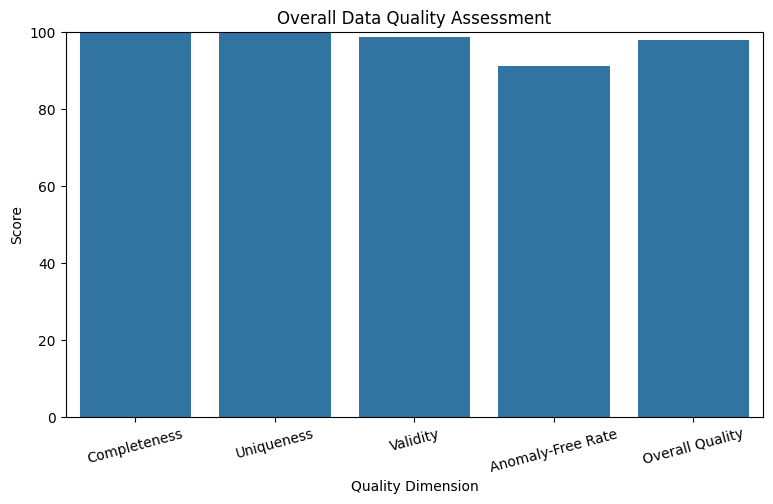

In [10]:
# ============================================================
# STEP 10 — FINAL DATA QUALITY DASHBOARD
# ============================================================

print("=" * 80)
print("FINAL DATA QUALITY DASHBOARD")
print("=" * 80)

print(
    f"\nDataset Size          : "
    f"{len(df):,} rows × {len(df.columns)} columns"
)

print(
    f"Missing Values        : "
    f"{df.isnull().sum().sum():,}"
)

print(
    f"Duplicate Records     : "
    f"{duplicate_count:,}"
)

print(
    f"Overall Quality Score : "
    f"{overall_quality_score:.2f}/100"
)

# ------------------------------------------------------------
# Anomaly statistics
# ------------------------------------------------------------

anomaly_count = (
    anomaly_df[
        "Anomaly_Status"
    ] == "Anomaly"
).sum()

anomaly_percentage = (
    anomaly_count
    / len(df)
    * 100
)

print(
    f"ML Anomalies          : "
    f"{anomaly_count:,}"
)

print(
    f"Anomaly Rate          : "
    f"{anomaly_percentage:.2f}%"
)

# ------------------------------------------------------------
# Severity summary
# ------------------------------------------------------------

if len(issue_register) > 0:

    severity_summary = (
        issue_register[
            "Severity"
        ]
        .value_counts()
    )

    print(
        "\nIssue Severity:"
    )

    display(
        severity_summary
    )

# ------------------------------------------------------------
# Quality dimensions chart
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=quality_score,
    x="Dimension",
    y="Score"
)

plt.ylim(
    0,
    100
)

plt.title(
    "Overall Data Quality Assessment"
)

plt.xlabel(
    "Quality Dimension"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=15
)

plt.show()

REVISED DATA QUALITY ASSESSMENT

Revised Validity Report:


,Column,Valid_Rows,Invalid_Rows,Validity_Rate
0,age,45211,0,100.0
1,day,45211,0,100.0
2,duration,45211,0,100.0
3,campaign,45211,0,100.0
4,pdays,45211,0,100.0
5,previous,45211,0,100.0



ML anomaly count : 905
ML anomaly rate  : 2.00%

Overall Quality Dimensions:


,Dimension,Score
0,Completeness,100.000000
1,Uniqueness,100.000000
2,Validity,100.000000
3,Outlier-Free Rate,91.143432
4,Overall Quality,98.228686



Revised Overall Data Quality Score: 98.23/100


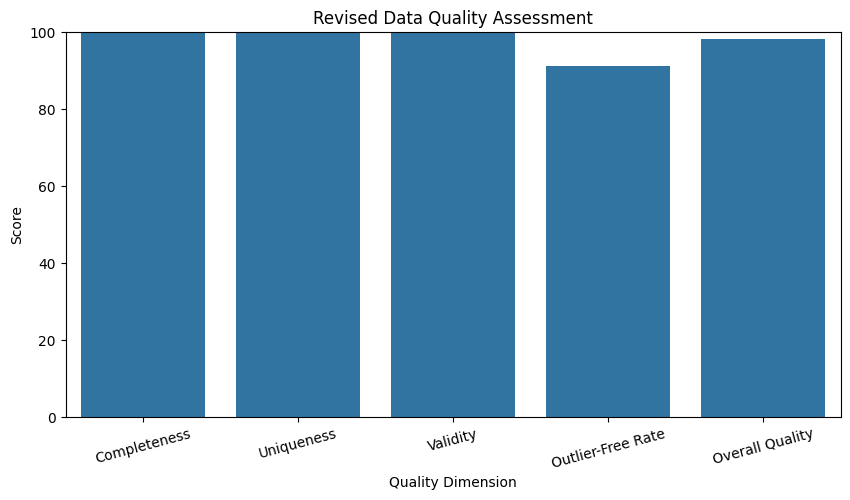

In [11]:
# ============================================================
# STEP 11 — REVISED DATA QUALITY ASSESSMENT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Define defensible validity rules
# ------------------------------------------------------------

validity_rules = {

    "age": (
        df["age"].between(18, 100)
    ),

    "day": (
        df["day"].between(1, 31)
    ),

    "duration": (
        df["duration"] >= 0
    ),

    "campaign": (
        df["campaign"] >= 1
    ),

    "pdays": (
        (df["pdays"] == -1)
        |
        (df["pdays"] >= 0)
    ),

    "previous": (
        df["previous"] >= 0
    )
}

# ------------------------------------------------------------
# 2. Build revised validity report
# ------------------------------------------------------------

revised_validity_rows = []

for column, condition in validity_rules.items():

    valid_count = int(
        condition.sum()
    )

    invalid_count = int(
        (~condition).sum()
    )

    validity_rate = (
        valid_count
        / len(df)
        * 100
    )

    revised_validity_rows.append({
        "Column": column,
        "Valid_Rows": valid_count,
        "Invalid_Rows": invalid_count,
        "Validity_Rate": validity_rate
    })

revised_validity_report = pd.DataFrame(
    revised_validity_rows
)

# ------------------------------------------------------------
# 3. Completeness
# ------------------------------------------------------------

completeness_score = (
    1
    -
    df.isnull().sum().sum()
    /
    (df.shape[0] * df.shape[1])
) * 100

# ------------------------------------------------------------
# 4. Uniqueness
# ------------------------------------------------------------

duplicate_count = (
    df.duplicated().sum()
)

uniqueness_score = (
    1
    -
    duplicate_count / len(df)
) * 100

# ------------------------------------------------------------
# 5. Validity
# ------------------------------------------------------------

validity_score = (
    revised_validity_report[
        "Validity_Rate"
    ].mean()
)

# ------------------------------------------------------------
# 6. Statistical outlier rate
# ------------------------------------------------------------

average_outlier_rate = (
    outlier_report[
        "Outlier_Percentage"
    ].mean()
)

outlier_free_score = max(
    0,
    100 - average_outlier_rate
)

# ------------------------------------------------------------
# 7. ML anomaly rate
# ------------------------------------------------------------

anomaly_count = (
    anomaly_df[
        "Anomaly_Status"
    ] == "Anomaly"
).sum()

anomaly_rate = (
    anomaly_count
    / len(df)
    * 100
)

# Outlier/anomaly observations are not automatically
# classified as invalid data.
# Therefore they are reported separately from validity.

# ------------------------------------------------------------
# 8. Revised overall quality score
# ------------------------------------------------------------

revised_quality_score = (
    completeness_score * 0.30
    +
    uniqueness_score * 0.20
    +
    validity_score * 0.30
    +
    outlier_free_score * 0.20
)

# ------------------------------------------------------------
# 9. Quality report
# ------------------------------------------------------------

revised_quality_report = pd.DataFrame({
    "Dimension": [
        "Completeness",
        "Uniqueness",
        "Validity",
        "Outlier-Free Rate",
        "Overall Quality"
    ],
    "Score": [
        completeness_score,
        uniqueness_score,
        validity_score,
        outlier_free_score,
        revised_quality_score
    ]
})

# ------------------------------------------------------------
# 10. Print results
# ------------------------------------------------------------

print("=" * 80)
print("REVISED DATA QUALITY ASSESSMENT")
print("=" * 80)

print("\nRevised Validity Report:")
display(
    revised_validity_report
)

print(
    f"\nML anomaly count : "
    f"{anomaly_count:,}"
)

print(
    f"ML anomaly rate  : "
    f"{anomaly_rate:.2f}%"
)

print("\nOverall Quality Dimensions:")
display(
    revised_quality_report
)

print(
    f"\nRevised Overall Data Quality Score: "
    f"{revised_quality_score:.2f}/100"
)

# ------------------------------------------------------------
# 11. Visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=revised_quality_report,
    x="Dimension",
    y="Score"
)

plt.ylim(
    0,
    100
)

plt.title(
    "Revised Data Quality Assessment"
)

plt.xlabel(
    "Quality Dimension"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=15
)

plt.show()

In [12]:
# ============================================================
# STEP 12 — AUTOMATED DATA QUALITY MONITORING
# ============================================================

import pandas as pd
import numpy as np
from datetime import datetime

# ------------------------------------------------------------
# 1. Monitoring thresholds
# ------------------------------------------------------------

THRESHOLDS = {
    "missing_rate": 1.0,
    "duplicate_rate": 1.0,
    "invalid_rate": 1.0,
    "anomaly_rate": 5.0
}

# ------------------------------------------------------------
# 2. Calculate monitoring metrics
# ------------------------------------------------------------

total_cells = (
    df.shape[0]
    *
    df.shape[1]
)

missing_rate = (
    df.isnull().sum().sum()
    /
    total_cells
    * 100
)

duplicate_rate = (
    df.duplicated().mean()
    * 100
)

invalid_count = (
    revised_validity_report[
        "Invalid_Rows"
    ].sum()
)

invalid_rate = (
    invalid_count
    /
    (
        len(
            revised_validity_report
        )
        *
        len(df)
    )
    * 100
)

anomaly_rate = (
    anomaly_df[
        "Anomaly_Status"
    ].eq("Anomaly")
    .mean()
    * 100
)

# ------------------------------------------------------------
# 3. Determine status
# ------------------------------------------------------------

monitoring_rows = []

metrics = {
    "Missing Rate": (
        missing_rate,
        THRESHOLDS["missing_rate"]
    ),
    "Duplicate Rate": (
        duplicate_rate,
        THRESHOLDS["duplicate_rate"]
    ),
    "Invalid Rate": (
        invalid_rate,
        THRESHOLDS["invalid_rate"]
    ),
    "ML Anomaly Rate": (
        anomaly_rate,
        THRESHOLDS["anomaly_rate"]
    )
}

for metric, (value, threshold) in metrics.items():

    if value > threshold:
        status = "ALERT"
    else:
        status = "PASS"

    monitoring_rows.append({
        "Metric": metric,
        "Current_Value": value,
        "Threshold": threshold,
        "Status": status
    })

monitoring_report = pd.DataFrame(
    monitoring_rows
)

# ------------------------------------------------------------
# 4. Add quality score
# ------------------------------------------------------------

monitoring_report.loc[
    len(monitoring_report)
] = [
    "Overall Quality Score",
    revised_quality_score,
    95.0,
    (
        "PASS"
        if revised_quality_score >= 95
        else "ALERT"
    )
]

# ------------------------------------------------------------
# 5. Display
# ------------------------------------------------------------

print("=" * 80)
print("AUTOMATED DATA QUALITY MONITORING")
print("=" * 80)

print(
    f"\nMonitoring Timestamp: "
    f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
)

display(
    monitoring_report
)

# ------------------------------------------------------------
# 6. Overall pipeline status
# ------------------------------------------------------------

alert_count = (
    monitoring_report[
        "Status"
    ] == "ALERT"
).sum()

if alert_count == 0:

    pipeline_status = "PASS"

else:

    pipeline_status = "ALERT"

print(
    "\nPipeline Status:",
    pipeline_status
)

print(
    "Number of alerts:",
    alert_count
)

AUTOMATED DATA QUALITY MONITORING

Monitoring Timestamp: 2026-08-27 02:58:08


,Metric,Current_Value,Threshold,Status
0,Missing Rate,0.000000,1.0,PASS
1,Duplicate Rate,0.000000,1.0,PASS
2,Invalid Rate,0.000000,1.0,PASS
3,ML Anomaly Rate,2.001725,5.0,PASS
4,Overall Quality Score,98.228686,95.0,PASS



Pipeline Status: PASS
Number of alerts: 0


In [13]:
# ============================================================
# STEP 13 — DATA ISSUE PRIORITIZATION
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Statistical outlier issues
# ------------------------------------------------------------

issue_rows = []

for _, row in outlier_report.iterrows():

    rate = row["Outlier_Percentage"]

    if rate >= 10:
        severity = "High"
    elif rate >= 5:
        severity = "Medium"
    else:
        severity = "Low"

    issue_rows.append({
        "Issue_Type": "Statistical Outlier",
        "Field": row["Feature"],
        "Issue_Count": int(row["Outliers"]),
        "Issue_Rate": rate,
        "Severity": severity
    })

# ------------------------------------------------------------
# 2. Validity issues
# ------------------------------------------------------------

for _, row in revised_validity_report.iterrows():

    if row["Invalid_Rows"] > 0:

        rate = (
            100
            -
            row["Validity_Rate"]
        )

        if rate >= 10:
            severity = "High"
        elif rate >= 5:
            severity = "Medium"
        else:
            severity = "Low"

        issue_rows.append({
            "Issue_Type": "Validity",
            "Field": row["Column"],
            "Issue_Count": int(
                row["Invalid_Rows"]
            ),
            "Issue_Rate": rate,
            "Severity": severity
        })

# ------------------------------------------------------------
# 3. ML anomaly issues
# ------------------------------------------------------------

ml_anomaly_count = (
    anomaly_df[
        "Anomaly_Status"
    ].eq("Anomaly")
    .sum()
)

ml_anomaly_rate = (
    ml_anomaly_count
    / len(df)
    * 100
)

issue_rows.append({
    "Issue_Type": "ML Anomaly",
    "Field": "Customer Record",
    "Issue_Count": int(
        ml_anomaly_count
    ),
    "Issue_Rate": ml_anomaly_rate,
    "Severity": (
        "High"
        if ml_anomaly_rate >= 5
        else "Medium"
        if ml_anomaly_rate >= 2
        else "Low"
    )
})

# ------------------------------------------------------------
# 4. Create register
# ------------------------------------------------------------

issue_register_v2 = pd.DataFrame(
    issue_rows
)

severity_order = {
    "High": 1,
    "Medium": 2,
    "Low": 3
}

issue_register_v2[
    "Severity_Order"
] = (
    issue_register_v2[
        "Severity"
    ]
    .map(severity_order)
)

issue_register_v2 = (
    issue_register_v2
    .sort_values(
        [
            "Severity_Order",
            "Issue_Rate"
        ],
        ascending=[
            True,
            False
        ]
    )
    .drop(
        columns="Severity_Order"
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("DATA ISSUE PRIORITIZATION")
print("=" * 80)

display(
    issue_register_v2
)

DATA ISSUE PRIORITIZATION


,Issue_Type,Field,Issue_Count,Issue_Rate,Severity
0,Statistical Outlier,previous,8257,18.263255,High
1,Statistical Outlier,pdays,8257,18.263255,High
2,Statistical Outlier,balance,4729,10.459844,High
3,Statistical Outlier,duration,3235,7.155338,Medium
4,Statistical Outlier,campaign,3064,6.777112,Medium
5,ML Anomaly,Customer Record,905,2.001725,Medium
6,Statistical Outlier,age,487,1.077171,Low
7,Statistical Outlier,day,0,0.000000,Low


In [14]:
# ============================================================
# STEP 14 — AUTOMATED DATA REMEDIATION SIMULATION
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Create a controlled corrupted copy
# ------------------------------------------------------------

df_corrupted = df.copy()

rng = np.random.default_rng(
    42
)

# ------------------------------------------------------------
# 2. Inject synthetic missing values
# ------------------------------------------------------------

missing_indices = rng.choice(
    df_corrupted.index,
    size=100,
    replace=False
)

df_corrupted.loc[
    missing_indices,
    "age"
] = np.nan

# ------------------------------------------------------------
# 3. Inject synthetic invalid values
# ------------------------------------------------------------

invalid_indices = rng.choice(
    df_corrupted.index,
    size=50,
    replace=False
)

df_corrupted.loc[
    invalid_indices,
    "age"
] = 5

# ------------------------------------------------------------
# 4. Inject synthetic duplicate rows
# ------------------------------------------------------------

duplicate_indices = rng.choice(
    df_corrupted.index,
    size=50,
    replace=False
)

synthetic_duplicates = (
    df_corrupted.loc[
        duplicate_indices
    ]
    .copy()
)

df_corrupted = pd.concat(
    [
        df_corrupted,
        synthetic_duplicates
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# 5. Before remediation report
# ------------------------------------------------------------

before_missing = (
    df_corrupted.isnull()
    .sum()
    .sum()
)

before_duplicates = (
    df_corrupted.duplicated()
    .sum()
)

before_invalid_age = (
    (
        (df_corrupted["age"] < 18)
        |
        (df_corrupted["age"] > 100)
    )
    .sum()
)

print("=" * 80)
print("BEFORE REMEDIATION")
print("=" * 80)

print(
    f"Rows             : "
    f"{len(df_corrupted):,}"
)

print(
    f"Missing values   : "
    f"{before_missing:,}"
)

print(
    f"Duplicates       : "
    f"{before_duplicates:,}"
)

print(
    f"Invalid ages     : "
    f"{before_invalid_age:,}"
)

# ------------------------------------------------------------
# 6. Remediation
# ------------------------------------------------------------

# Remove duplicates
df_clean = (
    df_corrupted
    .drop_duplicates()
    .copy()
)

# Correct invalid ages
invalid_age_mask = (
    (df_clean["age"] < 18)
    |
    (df_clean["age"] > 100)
)

df_clean.loc[
    invalid_age_mask,
    "age"
] = np.nan

# Impute missing age with median
age_median = (
    df["age"].median()
)

df_clean["age"] = (
    df_clean["age"]
    .fillna(age_median)
)

# ------------------------------------------------------------
# 7. After remediation
# ------------------------------------------------------------

after_missing = (
    df_clean.isnull()
    .sum()
    .sum()
)

after_duplicates = (
    df_clean.duplicated()
    .sum()
)

after_invalid_age = (
    (
        (df_clean["age"] < 18)
        |
        (df_clean["age"] > 100)
    )
    .sum()
)

print("\n" + "=" * 80)
print("AFTER REMEDIATION")
print("=" * 80)

print(
    f"Rows             : "
    f"{len(df_clean):,}"
)

print(
    f"Missing values   : "
    f"{after_missing:,}"
)

print(
    f"Duplicates       : "
    f"{after_duplicates:,}"
)

print(
    f"Invalid ages     : "
    f"{after_invalid_age:,}"
)

# ------------------------------------------------------------
# 8. Remediation summary
# ------------------------------------------------------------

remediation_summary = pd.DataFrame({
    "Metric": [
        "Missing Values",
        "Duplicates",
        "Invalid Ages"
    ],
    "Before": [
        before_missing,
        before_duplicates,
        before_invalid_age
    ],
    "After": [
        after_missing,
        after_duplicates,
        after_invalid_age
    ]
})

print(
    "\nRemediation Summary:"
)

display(
    remediation_summary
)

BEFORE REMEDIATION
Rows             : 45,261
Missing values   : 100
Duplicates       : 50
Invalid ages     : 50

AFTER REMEDIATION
Rows             : 45,211
Missing values   : 0
Duplicates       : 0
Invalid ages     : 0

Remediation Summary:


,Metric,Before,After
0,Missing Values,100,0
1,Duplicates,50,0
2,Invalid Ages,50,0


EXECUTIVE DATA QUALITY DASHBOARD


,KPI,Value
0,Total Records,45211
1,Total Fields,17
2,Missing Values,0
3,Duplicate Records,0
4,Overall Quality Score,98.23
5,ML Anomalies,905
6,ML Anomaly Rate,2.0
7,Pipeline Status,PASS



QUALITY DIMENSIONS


,Dimension,Score
0,Completeness,100.000000
1,Uniqueness,100.000000
2,Validity,100.000000
3,Outlier-Free Rate,91.143432
4,Overall Quality,98.228686



TOP DATA QUALITY ISSUES


,Issue_Type,Field,Issue_Count,Issue_Rate,Severity
0,Statistical Outlier,previous,8257,18.263255,High
1,Statistical Outlier,pdays,8257,18.263255,High
2,Statistical Outlier,balance,4729,10.459844,High
3,Statistical Outlier,duration,3235,7.155338,Medium
4,Statistical Outlier,campaign,3064,6.777112,Medium
5,ML Anomaly,Customer Record,905,2.001725,Medium
6,Statistical Outlier,age,487,1.077171,Low
7,Statistical Outlier,day,0,0.000000,Low



ANOMALY SUMMARY


,Status,Count,Percentage
0,Normal,44306,97.998275
1,Anomaly,905,2.001725



ISSUE SEVERITY


,Severity,Issue_Count
0,High,3
1,Medium,3
2,Low,2


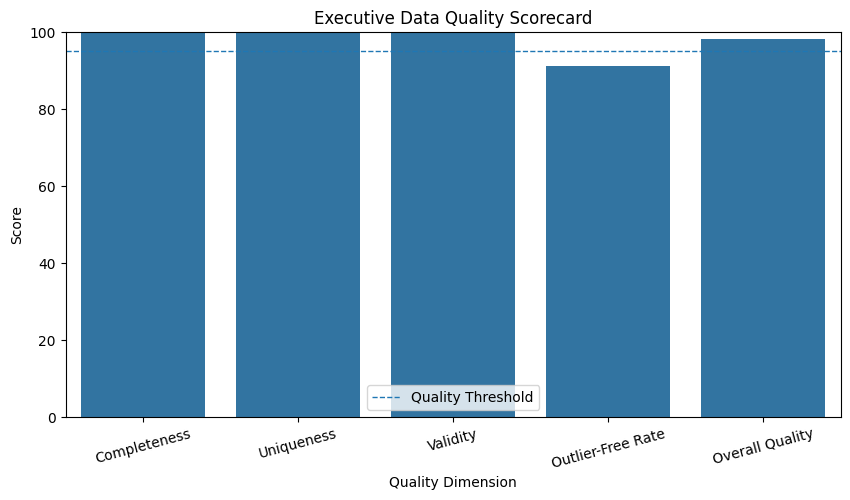

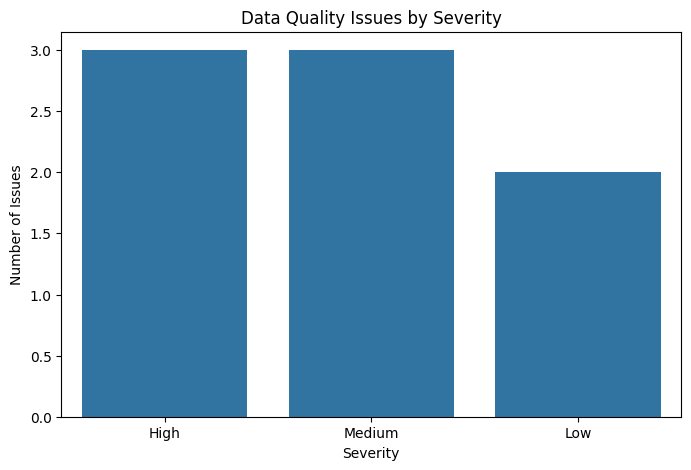


EXECUTIVE CONCLUSION
Overall data quality is strong with a score of 98.23/100.
905 records (2.00%) were identified as potential anomalies by the machine learning monitoring layer.

The highest-priority issues should be reviewed based on severity and issue rate.

Automated remediation successfully demonstrated the ability to correct synthetic data-quality problems involving missing values, duplicates, and invalid age records.


In [15]:
# ============================================================
# STEP 15 — EXECUTIVE DATA QUALITY DASHBOARD
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Core KPIs
# ------------------------------------------------------------

executive_kpis = pd.DataFrame({
    "KPI": [
        "Total Records",
        "Total Fields",
        "Missing Values",
        "Duplicate Records",
        "Overall Quality Score",
        "ML Anomalies",
        "ML Anomaly Rate",
        "Pipeline Status"
    ],
    "Value": [
        len(df),
        len(df.columns),
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        round(revised_quality_score, 2),
        int(anomaly_count),
        round(anomaly_rate, 2),
        pipeline_status
    ]
})

print("=" * 80)
print("EXECUTIVE DATA QUALITY DASHBOARD")
print("=" * 80)

display(
    executive_kpis
)

# ------------------------------------------------------------
# 2. Quality dimensions
# ------------------------------------------------------------

print("\nQUALITY DIMENSIONS")
print("=" * 80)

display(
    revised_quality_report
)

# ------------------------------------------------------------
# 3. Top data quality issues
# ------------------------------------------------------------

print("\nTOP DATA QUALITY ISSUES")
print("=" * 80)

top_issues = (
    issue_register_v2
    .head(10)
    .copy()
)

display(
    top_issues
)

# ------------------------------------------------------------
# 4. Anomaly distribution
# ------------------------------------------------------------

anomaly_summary = (
    anomaly_df[
        "Anomaly_Status"
    ]
    .value_counts()
    .reset_index()
)

anomaly_summary.columns = [
    "Status",
    "Count"
]

anomaly_summary[
    "Percentage"
] = (
    anomaly_summary["Count"]
    / len(anomaly_df)
    * 100
)

print("\nANOMALY SUMMARY")
print("=" * 80)

display(
    anomaly_summary
)

# ------------------------------------------------------------
# 5. Severity distribution
# ------------------------------------------------------------

severity_summary = (
    issue_register_v2[
        "Severity"
    ]
    .value_counts()
    .reindex(
        ["High", "Medium", "Low"],
        fill_value=0
    )
    .reset_index()
)

severity_summary.columns = [
    "Severity",
    "Issue_Count"
]

print("\nISSUE SEVERITY")
print("=" * 80)

display(
    severity_summary
)

# ------------------------------------------------------------
# 6. Dashboard — quality dimensions
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=revised_quality_report,
    x="Dimension",
    y="Score"
)

plt.ylim(0, 100)

plt.axhline(
    95,
    linestyle="--",
    linewidth=1,
    label="Quality Threshold"
)

plt.title(
    "Executive Data Quality Scorecard"
)

plt.xlabel(
    "Quality Dimension"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=15
)

plt.legend()

plt.show()

# ------------------------------------------------------------
# 7. Dashboard — issue severity
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=severity_summary,
    x="Severity",
    y="Issue_Count"
)

plt.title(
    "Data Quality Issues by Severity"
)

plt.xlabel(
    "Severity"
)

plt.ylabel(
    "Number of Issues"
)

plt.show()

# ------------------------------------------------------------
# 8. Executive conclusion
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXECUTIVE CONCLUSION")
print("=" * 80)

if revised_quality_score >= 95:

    print(
        f"Overall data quality is strong with a score "
        f"of {revised_quality_score:.2f}/100."
    )

else:

    print(
        f"Overall data quality requires attention with "
        f"a score of {revised_quality_score:.2f}/100."
    )

print(
    f"{anomaly_count:,} records "
    f"({anomaly_rate:.2f}%) were identified as "
    "potential anomalies by the machine learning "
    "monitoring layer."
)

if len(top_issues) > 0:

    print(
        "\nThe highest-priority issues should be "
        "reviewed based on severity and issue rate."
    )

print(
    "\nAutomated remediation successfully demonstrated "
    "the ability to correct synthetic data-quality "
    "problems involving missing values, duplicates, "
    "and invalid age records."
)

## Key Findings

### 1. The dataset demonstrates strong structural data quality

The dataset contains 45,211 records across 17 fields with no missing values and no duplicate records.

Both completeness and uniqueness achieved 100%, indicating that the dataset is structurally clean under the evaluated dimensions.

### 2. Business-rule validation achieved 100% validity

All monitored business-rule fields passed the defined validity checks.

This indicates that no observations violated the validation rules used in this project.

### 3. Statistical outliers remain an important monitoring area

The Outlier-Free Rate was 91.14%.

The main statistical outlier concentrations were observed in:

- previous
- pdays
- balance
- duration
- campaign

These observations should not automatically be treated as erroneous data because statistical outliers may represent legitimate customer behavior.

### 4. Machine learning identified potential anomalies

Isolation Forest identified 905 observations, representing approximately 2.00% of the dataset, as potential anomalies.

These observations can be prioritized for additional investigation instead of being automatically removed.

### 5. The overall data quality score reached 98.23/100

The dataset achieved an overall quality score of 98.23/100 under the evaluation framework defined in this project.

The strongest dimensions were completeness, uniqueness, and validity.

The main area requiring monitoring was statistical anomaly behavior.

### 6. Automated monitoring successfully produced a PASS status

All defined monitoring metrics remained below their configured alert thresholds.

The pipeline therefore returned a PASS status.

### 7. Automated remediation successfully corrected synthetic data issues

A controlled corruption experiment introduced missing values, duplicate records, and invalid age values.

The remediation pipeline successfully reduced all three simulated issue types to zero.

This demonstrates the ability of the workflow to support automated data-quality remediation.

## Business Recommendations

### Prioritize High-Severity Data Issues

Fields with high anomaly or outlier rates should receive priority during data quality review.

The fields `previous`, `pdays`, and `balance` should receive additional investigation because they contained the highest proportion of statistical outliers.

### Do Not Automatically Delete Outliers

Statistical outliers should be reviewed before removal.

Extreme values may represent legitimate customer behavior rather than incorrect records.

A business-rule validation layer should therefore be used together with statistical anomaly detection.

### Introduce Continuous Data Quality Monitoring

The quality checks implemented in this project can be converted into a recurring monitoring process.

Each incoming data batch can be evaluated for:

- Completeness
- Uniqueness
- Validity
- Outlier behavior
- ML-based anomalies

### Use Severity-Based Issue Management

Detected issues should be prioritized based on severity rather than treating all anomalies equally.

High-severity issues should be investigated first, followed by medium- and low-severity findings.

### Add Remediation Workflows

Frequently occurring and well-defined data-quality issues can be automatically corrected using controlled remediation rules.

More ambiguous anomalies should instead be routed for manual review.

### Maintain Data Lineage and Audit Logs

In a production environment, each remediation action should be recorded so that changes to source data remain traceable.

This would improve governance, accountability, and auditability.

## Conclusion

This project developed a data quality monitoring and anomaly detection framework for financial customer data.

The workflow combined data profiling, business-rule validation, statistical outlier detection, machine learning anomaly detection, issue prioritization, automated monitoring, and data remediation.

The final dataset contained 45,211 records and 17 fields with zero missing values and zero duplicate records.

The resulting data quality assessment achieved:

- Completeness: **100%**
- Uniqueness: **100%**
- Validity: **100%**
- Outlier-Free Rate: **91.14%**
- Overall Data Quality Score: **98.23/100**

Isolation Forest identified 905 potential anomalies, representing approximately 2.00% of the dataset.

The issue prioritization stage identified `previous`, `pdays`, and `balance` as the most significant statistical outlier areas.

Importantly, statistical outliers were treated as signals for investigation rather than automatically classified as data errors.

A controlled data corruption experiment was also performed to evaluate the remediation pipeline. The system successfully corrected synthetic missing values, duplicates, and invalid age records.

Overall, the project demonstrates how data quality management can be combined with statistical and machine learning techniques to create a more proactive data monitoring workflow.

The resulting framework can serve as a foundation for enterprise data observability systems that continuously assess data health, detect anomalies, prioritize issues, and support automated remediation.